# Stock Market Anomaly Detection

## Initial Setup

In [1]:
import sys
from pathlib import Path


BASE_DIR = Path.cwd()

# go UP until we find 'src'
while BASE_DIR != BASE_DIR.parent:
    if (BASE_DIR / "src").exists():
        break
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR / "src"))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from models.isolation_forest import IsolationForest
from models.dbscan import DBSCAN
from datetime import date, datetime
from dateutil.relativedelta import relativedelta


import warnings

warnings.filterwarnings("ignore")

## Configuration


In [ ]:
data_type = "intraday"
timeframe = "5min"

# data_type = "interday"
# timeframe = "1D"

stock_name = "NABIL"
features = ["close", "volume", "returns", "volatility"]



## Data Loading and Filtering


In [3]:
# Data type
if data_type == "intraday":

    all_days = []
    start_date = datetime.strptime("2026-04-09", "%Y-%m-%d")
    end_date = datetime.strptime("2026-04-30", "%Y-%m-%d")

    for date_folder in sorted(Path("./../../data/intraday").iterdir()):
        if not date_folder.is_dir():
            continue

        date = datetime.strptime(date_folder.name, "%Y-%m-%d")
        if start_date <= date <= end_date:
            file_path = date_folder / f"{stock_name}.csv"

            if file_path.exists():
                df = pd.read_csv(file_path)
                df["transaction_time"] = pd.to_datetime(df["transaction_time"])
                df = df.set_index("transaction_time")
                df = df.sort_index()

                all_days.append(df)

    if not all_days:
        # if no data found returns an empty dataframe
        df = pd.DataFrame()
    else:
        # returns a concatenated dataframe and ignore the index of the dataframe and generate a brand new set of indices
        df = pd.concat(all_days).sort_index()
        df = df.reset_index()


else:

    start_date = date.today() - relativedelta(years=3)
    end_date = date.today()

    print(start_date)
    print(end_date)

    data_source = stock_name + ".csv"

    df = pd.read_csv(f"{BASE_DIR}/data/interday/{data_source}")


df.head()

,transaction_time,contract_id,symbol,buyer_member_id,seller_member_id,volume,price,amount,buyer_broker,seller_broker
0,2026-04-09 11:02:29.665442,2026040901000442,NABIL,44,42,13,521.0,6773.0,Dynamic Money Managers Securities Pvt. Ltd.,Sani Securities Company Ltd.
1,2026-04-09 11:04:08.117627,2026040901000840,NABIL,35,47,20,526.0,10520.0,Kohinoor Investment & Securities Pvt. Ltd.,Neev Securities Pvt. Ltd.
2,2026-04-09 11:04:56.462076,2026040901001000,NABIL,57,47,480,526.0,252480.0,Aryatara Investment & Securities,Neev Securities Pvt. Ltd.
3,2026-04-09 11:05:34.949956,2026040901001107,NABIL,42,14,20,528.0,10560.0,Sani Securities Company Ltd.,Nepal Stock House (PVT) Ltd.
4,2026-04-09 11:06:25.720050,2026040901001312,NABIL,57,42,14,526.0,7364.0,Aryatara Investment & Securities,Sani Securities Company Ltd.


## Data Preprocessing

### Resampling/Aggregation

In [ ]:
df["Date"] = pd.to_datetime(df["transaction_time"])
df = df.set_index("Date")
df = df.sort_index()

if data_type == "interday":
    df = df.resample(timeframe).agg(
        open=("open", "first"),
        high=("high", "max"),
        low=("low", "min"),
        close=("close", "last"),
        volume=("volume", "sum"),
    )
elif data_type == "intraday":
    df = df.resample(timeframe).agg(
        open=("price", "first"),
        high=("price", "max"),
        low=("price", "min"),
        close=("price", "last"),
        volume=("volume", "sum"),
    )

### Data cleaning

In [ ]:
# print(df.columns)

df = df.loc[start_date:end_date].copy()

# drop unnecessary columns
df = df.drop(columns=["transaction_time"], errors="ignore")

# Filter dataframe
df = df.drop_duplicates()




close          1
volume         0
returns        1
volatility    20
dtype: int64


,open,high,low,close,volume,returns,volatility
Date,,,,,,,
2026-04-09 11:00:00,521.0,526.0,521.0,526.0,513,NaN,NaN
2026-04-09 11:05:00,528.0,528.0,526.0,526.0,279,0.000000,NaN
2026-04-09 11:10:00,525.0,525.0,523.0,523.0,500,-0.005703,NaN
2026-04-09 11:15:00,525.0,526.0,525.0,526.0,97,0.005736,NaN
2026-04-09 11:20:00,526.0,526.0,525.0,525.0,780,-0.001901,NaN


## Feature Engineering

### Compute Base features

In [ ]:
# Compute features
df["returns"] = df["close"].pct_change()
df["close"] = df["close"].replace(0, np.nan)
df["volatility"] = df["returns"].rolling(window=20).std()



print(df[["close", "volume", "returns", "volatility"]].isna().sum())


df[features] = df[features].apply(
    pd.to_numeric, errors="coerce"
)  
# converts every value in features columns to numeric value
df.replace(
    [np.inf, -np.inf], np.nan, inplace=True
)  
# replace inf and -inf 

# df = df.dropna(subset=features)  # drops rows where any of the features are NaN
# print(df[["close", "volume", "returns", "volatility"]].isna().sum())


df.head()

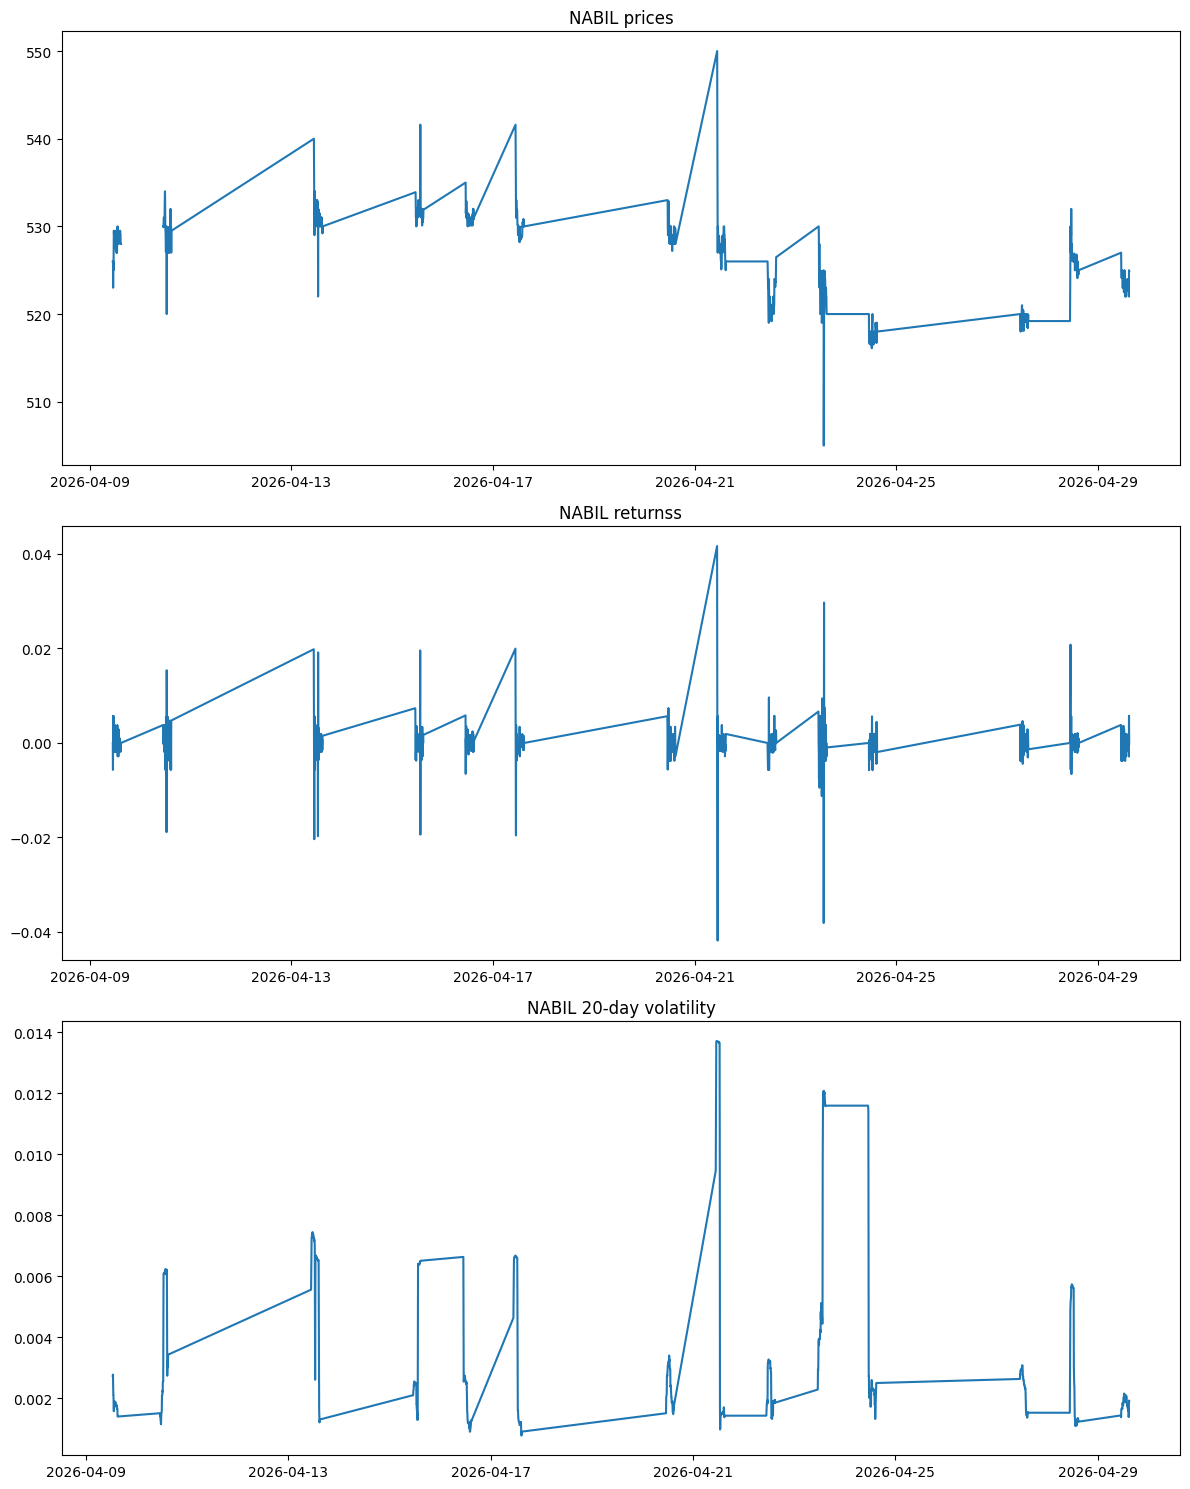

In [ ]:
# # Plot volatitlity and percent change

# fig, axes = plt.subplots(3, 1, figsize=(12, 15))
# axes[0].plot(df.index, df["close"])
# axes[0].set_title(f"{stock_name} prices")
# axes[1].plot(df.index, df["returns"])
# axes[1].set_title(f"{stock_name} returnss")
# axes[2].plot(df.index, df["volatility"])
# axes[2].set_title(f"{stock_name} 20-day volatility")
# plt.tight_layout()

# plt.show()

### Compute additional features

**SMA:** Simple moving average of last N Days
**RSI:** Relative strength index measures the speed and magnitude of recent price changes to evaluate overbought or oversold conditions  
Above 70 → asset may be overbought (close went up too fast, may pull back)  
Below 30 → asset may be oversold (close dropped too fast, may bounce back)  
Around 50 → neutral momentum
**Boilinger Bands:** It consists of a:
**Middle band:** a 20 day SMA
**Upper band:** middle band + 2*standard deviation
**Lower band:** middle band - 2*standard deviation  

Wide bands->volatile market
Price near upperband -> overbought
Price near lowerband -> oversold  

When price moves outside this band means theres a breakout






In [ ]:
# Feature Enginneering


# 1. Calculate Simple moving averages of last N days

df["SMA_10"] = df["close"].rolling(window=10).mean()
df["SMA_20"] = df["close"].rolling(window=20).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()


# 2. Calculate Relative Strength Index
def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


df["RSI"] = calculate_rsi(df["close"])





# 3. Calculate Boilinger bands
df["Upper_BB"] = df["SMA_20"] + (df["close"].rolling(window=20).std() * 2)
df["Lower_BB"] = df["SMA_20"] - (df["close"].rolling(window=20).std() * 2)

df.tail()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB
Date,,,,,,,,,,,,,
2026-04-29 14:35:00,523.0,523.5,522.0,523.5,544,0.001722,0.001643,523.38,523.170,523.948,60.869565,524.377172,521.962828
2026-04-29 14:40:00,522.1,523.9,522.0,523.5,1964,0.000000,0.001383,523.43,523.245,523.898,54.237288,524.325887,522.164113
2026-04-29 14:45:00,523.9,523.9,522.0,522.0,1554,-0.002865,0.001471,523.24,523.195,523.836,43.243243,524.408043,521.981957
2026-04-29 14:50:00,523.9,525.0,523.5,525.0,2350,0.005747,0.001926,523.44,523.245,523.836,62.000000,524.662893,521.827107
2026-04-29 14:55:00,525.0,525.0,524.0,524.9,967,-0.000190,0.001911,523.63,523.315,523.844,59.793814,524.912729,521.717271


In [9]:
# Plot technical analysis
import plotly.graph_objects as go


# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close",
        line=dict(color="blue", width=2),
    )
)

# Add 'SMA 10' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_10"],
        mode="lines",
        name="SMA 10",
        line=dict(color="green", width=2, dash="dot"),
    )
)

# Add 'SMA 50' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_50"],
        mode="lines",
        name="SMA 50",
        line=dict(color="orange", width=2, dash="dash"),
    )
)

# Add 'Upper BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Upper_BB"],
        mode="lines",
        name="Upper BB",
        line=dict(color="red", width=1, dash="dot"),
    )
)

# Add 'Lower BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Lower_BB"],
        mode="lines",
        name="Lower BB",
        line=dict(color="purple", width=1, dash="dot"),
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock close with Technical Indicators",
    xaxis_title="Date",
    yaxis_title="Stock close",
    legend=dict(
        x=0, y=1, bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)"
    ),
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

## Anomaly Injection

Due to lack of labeled intraday anomaly data, an anomaly injection & evaluation strategy was used with  synthetic anomaly injection to approximate realistic market anomalies


In [ ]:
import numpy as np

fraction = 0.01
price_range = (0.15, 0.30)
vol_multiplier = (3, 8)
window_size = (3, 8)  
#anomaly lasts 3-8 candles

df["True_Anomaly"] = 0

n = len(df)
k = int(n * fraction)

idxs = np.random.choice(range(n - max(window_size)), size=k, replace=False)
#pick random start_idx  for anomaly injection without going out of bounds and dont replace the chosen idx such as every index is unique

for start_idx in idxs:
    # get a random window length. * means to unpack the tuple
    length = np.random.randint(*window_size) 

    #make a random choice between 3 options
    #pump means price jump, dump is price crash and volume spike is jump in stocks traded
    choice = np.random.choice(["pump", "dump", "volume_spike"])

    for i in range(start_idx, start_idx + length):

        #accesses dataframe like df.iloc[row,col] and marks the row as anomalous, here col is the actual column index of True_Anomaly in the dataframe.
        df.iloc[i, df.columns.get_loc("True_Anomaly")] = 1

        if choice in ["pump", "dump"]:

            #choose a random multiplier in the price_range
            factor = np.random.uniform(*price_range)
            if choice == "dump":
                factor *= -1

            for col in ["open", "high", "low", "close"]:
                col_idx = df.columns.get_loc(col)
                df.iloc[i, col_idx] *= (1 + factor)

        elif choice == "volume_spike":
            col_idx = df.columns.get_loc("volume")
            df.iloc[i, col_idx] *= np.random.uniform(*vol_multiplier)

#cast the column as a pure int
df["True_Anomaly"] = df["True_Anomaly"].astype(int)

#recalculate the features
df["returns"] = df["close"].pct_change()
df["volatility"] = df["returns"].rolling(20).std()


print("Anomalies Injected: ",len(df[df["True_Anomaly"]==1]))





32
32


In [ ]:
#drop na values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=features,inplace=True)

# Hyperparameter tuning

Find the best parameters between a combination of parameters for the given models

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.stats import zscore
from itertools import product
import warnings
warnings.filterwarnings("ignore")



def quick_tune_isolation_forest(X, y_true, verbose=True):
    """Quick tuning of Isolation Forest."""
    results = []
    
    param_grid = {
        'n_estimators': [100, 200, 300],
        'contamination': [0.005, 0.01, 0.02, 0.05]
    }
    
    combinations = list(product(
        param_grid['n_estimators'],
        param_grid['contamination']
    ))
    
    if verbose:
        print(f"Testing {len(combinations)} Isolation Forest combinations...")
    
    for n_est, contam in combinations:
        try:
            from models.isolation_forest import IsolationForest
            
            model = IsolationForest(
                n_trees=n_est,
                contamination=contam,
                random_state=42
            )
            
            predictions = model.fit_predict(X)
            predictions_binary = (predictions == -1).astype(int)
            
            # Skip if no anomalies
            if predictions_binary.sum() == 0:
                continue
            
            f1 = f1_score(y_true, predictions_binary, zero_division=0)
            precision = precision_score(y_true, predictions_binary, zero_division=0)
            recall = recall_score(y_true, predictions_binary, zero_division=0)
            
            results.append({
                'n_estimators': n_est,
                'contamination': contam,
                'f1_score': f1,
                'precision': precision,
                'recall': recall
            })
            
        except Exception as e:
            if verbose:
                print(f"  Error with n_est={n_est}, contam={contam}: {e}")
    
    if not results:
        # Return empty dataframe with proper structure
        return pd.DataFrame({
            'n_estimators': [200],
            'contamination': [0.01],
            'f1_score': [0.0],
            'precision': [0.0],
            'recall': [0.0]
        })
    
    results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
    
    if verbose:
        print(f"\n✓ Best F1-Score: {results_df.iloc[0]['f1_score']:.4f}")
        print(f"✓ Best Parameters: n_estimators={int(results_df.iloc[0]['n_estimators'])}, "
              f"contamination={results_df.iloc[0]['contamination']:.4f}\n")
    
    return results_df


def quick_tune_dbscan(X, y_true, verbose=True):
    """Quick tuning of DBSCAN."""
    from models.dbscan import DBSCAN
    
    results = []
    
    param_grid = {
        'eps': [0.5, 1.0, 1.5, 2.0],
        'min_pts': [5, 10, 15]
    }
    
    combinations = list(product(
        param_grid['eps'],
        param_grid['min_pts']
    ))
    
    if verbose:
        print(f"Testing {len(combinations)} DBSCAN combinations...")
    
    for eps, min_pts in combinations:
        try:
            model = DBSCAN(eps=eps, min_pts=min_pts)
            predictions = model.fit_predict(X)
            
            # FIX: Handle case where DBSCAN returns boolean or scalar
            if isinstance(predictions, (bool, np.bool_)):
                if verbose:
                    print(f"  Error with eps={eps}, min_pts={min_pts}: Invalid return type (boolean)")
                continue
            
            # Convert to numpy array if needed
            predictions = np.asarray(predictions)
            
            # Check if it's a scalar
            if predictions.ndim == 0:
                if verbose:
                    print(f"  Error with eps={eps}, min_pts={min_pts}: Scalar return value")
                continue
            
            # Now safe to convert to int
            predictions_binary = (predictions == -1).astype(int)
            
            if predictions_binary.sum() == 0:
                continue
            
            f1 = f1_score(y_true, predictions_binary, zero_division=0)
            precision = precision_score(y_true, predictions_binary, zero_division=0)
            recall = recall_score(y_true, predictions_binary, zero_division=0)
            
            results.append({
                'eps': eps,
                'min_pts': min_pts,
                'f1_score': f1,
                'precision': precision,
                'recall': recall
            })
            
        except Exception as e:
            if verbose:
                print(f"  Error with eps={eps}, min_pts={min_pts}: {str(e)[:60]}")
    
    if not results:
        # Return empty dataframe with proper structure
        return pd.DataFrame({
            'eps': [1.0],
            'min_pts': [5],
            'f1_score': [0.0],
            'precision': [0.0],
            'recall': [0.0]
        })
    
    results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
    
    if verbose:
        print(f"\n✓ Best F1-Score: {results_df.iloc[0]['f1_score']:.4f}")
        print(f"✓ Best Parameters: eps={results_df.iloc[0]['eps']:.2f}, "
              f"min_pts={int(results_df.iloc[0]['min_pts'])}\n")
    
    return results_df


def quick_tune_z_score(df, y_true, feature='close', verbose=True):
    """Quick tuning of Z-Score threshold."""
    
    results = []
    thresholds = np.arange(1.5, 4.5, 0.5)
    
    if verbose:
        print(f"Testing {len(thresholds)} Z-Score thresholds...")
    
    z_scores = zscore(df[feature].dropna())
    
    for threshold in thresholds:
        predictions_binary = (np.abs(z_scores) > threshold).astype(int)
        
        if predictions_binary.sum() == 0:
            continue
        
        # Need to align with y_true
        valid_idx = df[feature].notna()
        y_valid = y_true[valid_idx]
        
        if len(y_valid) != len(predictions_binary):
            continue
        
        f1 = f1_score(y_valid, predictions_binary, zero_division=0)
        precision = precision_score(y_valid, predictions_binary, zero_division=0)
        recall = recall_score(y_valid, predictions_binary, zero_division=0)
        
        results.append({
            'threshold': threshold,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'n_anomalies': predictions_binary.sum()
        })
    
    if not results:
        # Return empty dataframe with proper structure
        return pd.DataFrame({
            'threshold': [3.0],
            'f1_score': [0.0],
            'precision': [0.0],
            'recall': [0.0],
            'n_anomalies': [0]
        })
    
    results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
    
    if verbose:
        print(f"\n✓ Best F1-Score: {results_df.iloc[0]['f1_score']:.4f}")
        print(f"✓ Best Threshold: {results_df.iloc[0]['threshold']:.2f}\n")
    
    return results_df


#visualize the results

def plot_if_tuning(results_df):
    """Plot Isolation Forest tuning results."""
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        for n_est in results_df['n_estimators'].unique():
            subset = results_df[results_df['n_estimators'] == n_est].sort_values('contamination')
            axes[0].plot(subset['contamination'], subset['f1_score'], 
                        marker='o', label=f'n_est={int(n_est)}')
        
        axes[0].set_xlabel('Contamination')
        axes[0].set_ylabel('F1-Score')
        axes[0].set_title('Isolation Forest: F1-Score vs Contamination')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Top results
        top_10 = results_df.head(10).sort_values('f1_score')
        axes[1].barh(range(len(top_10)), top_10['f1_score'], color='steelblue')
        labels = [f"n_est={int(row['n_estimators'])}, cont={row['contamination']:.3f}" 
                  for _, row in top_10.iterrows()]
        axes[1].set_yticks(range(len(top_10)))
        axes[1].set_yticklabels(labels, fontsize=9)
        axes[1].set_xlabel('F1-Score')
        axes[1].set_title('Top 10 Parameter Combinations')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot Isolation Forest results: {e}")


def plot_dbscan_tuning(results_df):
    """Plot DBSCAN tuning results as heatmap."""
    try:
        import seaborn as sns
        
        # Check if we have enough data to pivot
        if len(results_df) < 2:
            print("Not enough DBSCAN results to plot")
            return
        
        # Pivot for heatmap
        pivot_table = results_df.pivot_table(
            index='min_pts',
            columns='eps',
            values='f1_score',
            aggfunc='mean'
        )
        
        if pivot_table.empty:
            print("Could not create pivot table for DBSCAN")
            return
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', 
                    cbar_kws={'label': 'F1-Score'})
        plt.title('DBSCAN: F1-Score Heatmap')
        plt.xlabel('eps')
        plt.ylabel('min_pts')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot DBSCAN results: {e}")


def plot_zscore_tuning(results_df):
    """Plot Z-Score tuning results."""
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].plot(results_df['threshold'], results_df['f1_score'], 
                    marker='o', color='red', linewidth=2, markersize=8)
        axes[0].set_xlabel('Threshold')
        axes[0].set_ylabel('F1-Score')
        axes[0].set_title('Z-Score: F1-Score vs Threshold')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(results_df['threshold'], results_df['n_anomalies'], 
                    marker='s', color='purple', linewidth=2, markersize=8)
        axes[1].set_xlabel('Threshold')
        axes[1].set_ylabel('Number of Anomalies')
        axes[1].set_title('Z-Score: Anomaly Count vs Threshold')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot Z-Score results: {e}")




def run_hyperparameter_tuning(df, features, verbose=True):
    """
    Complete hyperparameter tuning pipeline.
    
    Usage:
    ------
    best_params = run_hyperparameter_tuning(df, features=['close', 'volume', 'returns', 'volatility'])
    
    Returns:
    --------
    best_params : dict
        Dictionary with best parameters for each method
    """
    
    print("\n" + "="*60)
    print("HYPERPARAMETER TUNING FOR ANOMALY DETECTION")
    print("="*60 + "\n")
    
    # Create ground truth
    df["True_Anomaly"] = df["close"].pct_change().abs() > 0.05
    
    # Prepare data
    X = df[features].values
    X = StandardScaler().fit_transform(X)
    y_true = df["True_Anomaly"].values
    
    best_params = {}
    
    # =====================
    # 1. ISOLATION FOREST
    # =====================
    print(" TUNING ISOLATION FOREST")
    print("-" * 60)
    
    results_if = quick_tune_isolation_forest(X, y_true, verbose=verbose)
    
    best_params['isolation_forest'] = {
        'n_estimators': int(results_if.iloc[0]['n_estimators']),
        'contamination': float(results_if.iloc[0]['contamination'])
    }
    
    if verbose and len(results_if) > 0:
        print("Results:")
        print(results_if[['n_estimators', 'contamination', 'precision', 'recall', 'f1_score']].head())
    
    try:
        plot_if_tuning(results_if)
    except Exception as e:
        print(f"Could not plot Isolation Forest: {e}")
    
    # =====================
    # 2. DBSCAN
    # =====================
    print("\n TUNING DBSCAN")
    print("-" * 60)
    
    results_dbscan = quick_tune_dbscan(X, y_true, verbose=verbose)
    
    best_params['dbscan'] = {
        'eps': float(results_dbscan.iloc[0]['eps']),
        'min_pts': int(results_dbscan.iloc[0]['min_pts'])
    }
    
    if verbose and len(results_dbscan) > 0:
        print("Results:")
        cols_to_show = [c for c in ['eps', 'min_pts', 'precision', 'recall', 'f1_score'] 
                       if c in results_dbscan.columns]
        print(results_dbscan[cols_to_show].head())
    
    try:
        plot_dbscan_tuning(results_dbscan)
    except Exception as e:
        print(f"Could not plot DBSCAN: {e}")
    
    # =====================
    # 3. Z-SCORE
    # =====================
    print("\n TUNING Z-SCORE")
    print("-" * 60)
    
    results_zscore = quick_tune_z_score(df, y_true, verbose=verbose)
    
    best_params['z_score'] = {
        'threshold': float(results_zscore.iloc[0]['threshold'])
    }
    
    if verbose and len(results_zscore) > 0:
        print("Results:")
        print(results_zscore[['threshold', 'precision', 'recall', 'f1_score', 'n_anomalies']])
    
    try:
        plot_zscore_tuning(results_zscore)
    except Exception as e:
        print(f"Could not plot Z-Score: {e}")
    
    
    #Summary
    print("\n" + "="*60)
    print("SUMMARY OF BEST PARAMETERS")
    print("="*60)
    
    for method, params in best_params.items():
        print(f"\n{method.upper()}:")
        for param, value in params.items():
            print(f"  {param}: {value}")
    
    return best_params, {'if': results_if, 'dbscan': results_dbscan, 'zscore': results_zscore}


if __name__ == "__main__":
    print("This module is ready to be imported and used in your notebook.")
    print("\nUsage:")
    print("  best_params = run_hyperparameter_tuning(df, features=['close', 'volume', 'returns', 'volatility'])")

This module is ready to be imported and used in your notebook.

Usage:
  best_params = run_hyperparameter_tuning(df, features=['close', 'volume', 'returns', 'volatility'])



HYPERPARAMETER TUNING FOR ANOMALY DETECTION

1️⃣  TUNING ISOLATION FOREST
------------------------------------------------------------
Testing 12 Isolation Forest combinations...



✓ Best F1-Score: 0.7925
✓ Best Parameters: n_estimators=300, contamination=0.0500

Results:
    n_estimators  contamination  precision    recall  f1_score
11           300           0.05   0.656250  1.000000  0.792453
7            200           0.05   0.656250  1.000000  0.792453
3            100           0.05   0.636364  1.000000  0.777778
2            100           0.02   0.923077  0.571429  0.705882
6            200           0.02   0.923077  0.571429  0.705882


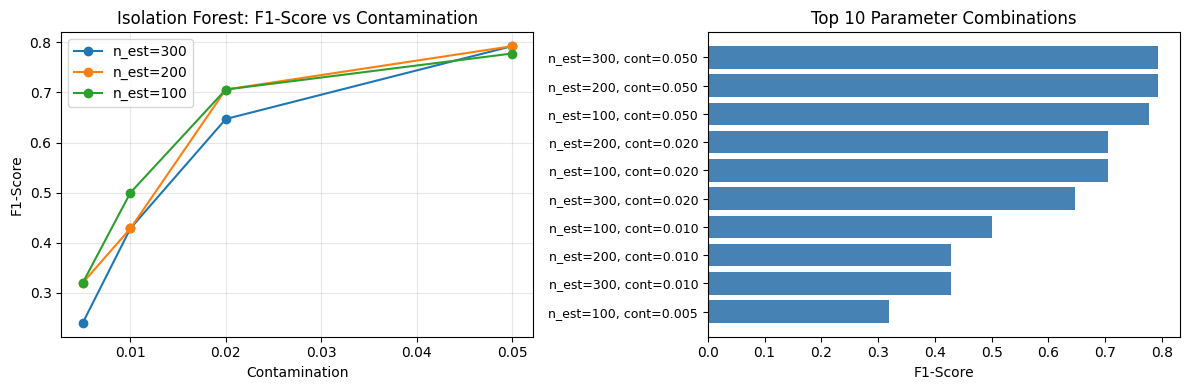


2️⃣  TUNING DBSCAN
------------------------------------------------------------
Testing 12 DBSCAN combinations...

✓ Best F1-Score: 0.8235
✓ Best Parameters: eps=1.00, min_pts=5

Results:
    eps  min_pts  precision  recall  f1_score
3   1.0        5   0.700000     1.0  0.823529
10  2.0       10   0.636364     1.0  0.777778
11  2.0       15   0.636364     1.0  0.777778
7   1.5       10   0.636364     1.0  0.777778
8   1.5       15   0.636364     1.0  0.777778


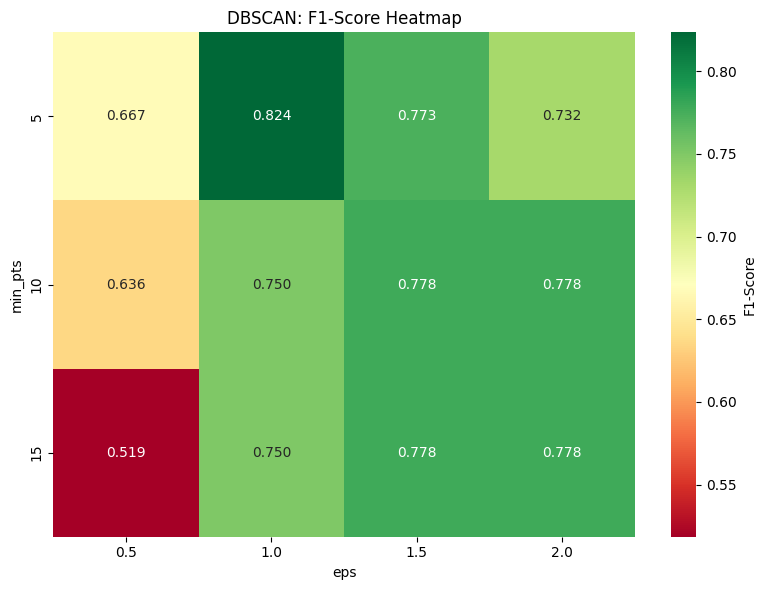


3️⃣  TUNING Z-SCORE
------------------------------------------------------------
Testing 6 Z-Score thresholds...

✓ Best F1-Score: 0.6809
✓ Best Threshold: 1.50

Results:
   threshold  precision    recall  f1_score  n_anomalies
0        1.5   0.615385  0.761905  0.680851           26
1        2.0   0.615385  0.761905  0.680851           26
2        2.5   0.615385  0.761905  0.680851           26
3        3.0   0.615385  0.761905  0.680851           26
4        3.5   0.583333  0.666667  0.622222           24
5        4.0   0.600000  0.571429  0.585366           20


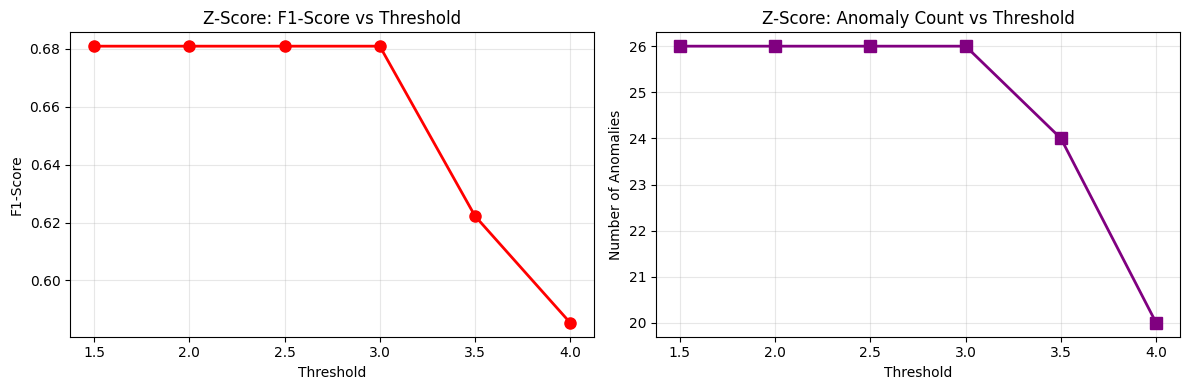


SUMMARY OF BEST PARAMETERS

ISOLATION_FOREST:
  n_estimators: 300
  contamination: 0.05

DBSCAN:
  eps: 1.0
  min_pts: 5

Z_SCORE:
  threshold: 1.5


In [ ]:
best_params, all_results = run_hyperparameter_tuning(df, features)

z_score_threshold = best_params['z_score']['threshold']

n_estimators = best_params['isolation_forest']['n_estimators']
contamination = best_params['isolation_forest']['contamination']

epsilon = best_params['dbscan']['eps']
min_samples = best_params['dbscan']['min_pts']

# Anomaly Detection Techniques

## Z Score

In [13]:
from scipy.stats import zscore
import plotly.graph_objects as go


# Calculate Z Score for close prices
df["Anomaly_Z_Score"] = zscore(df["close"])

# Identify anomalies where Z-Score >3 or < -3
anomalies_zscore = df[abs(df["Anomaly_Z_Score"]) > z_score_threshold]

# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Z-score > 3 or < -3) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"],
        mode="markers",
        name="Anomalies (Z-Score)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock prices with Anomalies Detected Using Z-Score",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()
# df.sort_values(by="Anomaly_Z_Score",ascending=False).head()
anomalies_zscore.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,True_Anomaly,Anomaly_Z_Score
Date,,,,,,,,,,,,,,,
2026-04-13 14:05:00,435.942211,436.764743,435.942211,436.764743,904.0,-0.175916,0.039812,530.70,530.525,530.948,55.263158,534.933067,526.116933,True,-3.643915
2026-04-13 14:10:00,396.505932,397.103304,395.759216,395.759216,111.0,-0.093885,0.044001,530.70,530.380,530.968,36.231884,534.647675,526.112325,True,-5.305028
2026-04-13 14:15:00,420.033229,420.112346,420.033229,420.112346,117.0,0.061535,0.047077,530.75,530.330,530.988,58.333333,534.540813,526.119187,True,-4.318495
2026-04-13 14:20:00,420.057755,420.136877,420.057755,420.136877,324.0,0.000058,0.047066,530.70,530.255,531.048,58.333333,534.355051,526.154949,False,-4.317501
2026-04-13 14:25:00,414.774376,414.774376,414.227593,414.227593,570.0,-0.014065,0.047025,530.63,530.670,531.044,52.238806,531.988851,529.351149,False,-4.556883


## Standardization

To standardize means to convert the data to have a mean of 0 and a standard deviation of 1 such that the data is normalized and the model can learn better
this is important because the model is sensitive to the scale of the data as returns maybe in the range of -0.2 to 0.2 but the other features are in the range of 1000 to 1000000 like quantity


In [14]:
# Only take the selected features
X = df[features]

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(np.isfinite(X).all())
print(pd.DataFrame(X).isna().sum())

True
0    0
1    0
2    0
3    0
dtype: int64


## Isolation Forest Approach

Anomalies are easier to isolate than normal points and
because anomalies are rare and far from the cluster, a random split can isolate them quickly.
Normal points are surrounded by many neighbors, so they require more splits

It takes 3 parameters:

**1. n_estimators:** 200 means 200 independent trees are built and then sees how quickly a given point gets isolated across these trees.  
**2. contamination:** 0.01 assumes that 1% of the data is anomalous  
**3. max_depth:** cap a trees height  
**4. random_state:** for reproducibility purposes as without it every run gives slightly different anomalies

Random seed → geneprice random splits  
 ↓  
Build 200 isolation trees  
 ↓  
Compute anomaly scores  
 ↓  
Use contamination (1%) to label anomalies

isolation forest converts the average path length to scores  
short path → high anomaly score  
long path → low anomaly score

max-depth = ceil(log2(max_samples))  
len(X) is how many training rows you have.  
np.log2(n) is “how many times can you halve n before you get down to ~1” — a standard rough size for depth in random/binary tree pictures.  
np.ceil(...) rounds up so you always get an integer depth.  
int(...) makes it a plain Python int for your IsolationForest.

if training data becomes huge we instead find depth by choosing a max-sample size to randomly select samples to cap a tree's height


In [15]:
# We can also train the model and fit it in test data, But for simplicity purposes we will fit the model on the entire dataset.

# split_idx = int(len(df) * 0.8) #splits the dataframe into 80% train and 20% test
# df_train = df.iloc[:split_idx].copy() #creates a copy of the train dataframe from the first 80% of the dataframe
# df_test = df.iloc[split_idx:].copy() #creates a copy of the test dataframe from the last 20% of the dataframe


model_if = IsolationForest(
    n_trees=n_estimators, contamination=contamination, random_state=42
)

df["Anomaly_Isolation_Forest"] = model_if.fit_predict(X)

anomalies_if = df[df["Anomaly_Isolation_Forest"] == -1]


anomalies_if.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,True_Anomaly,Anomaly_Z_Score,Anomaly_Isolation_Forest
Date,,,,,,,,,,,,,,,,
2026-04-10 14:15:00,520.000000,538.000000,520.000000,528.000000,30016.0,-0.003774,0.006115,528.50,528.045,NaN,50.000000,532.314093,523.775907,False,0.051980,-1
2026-04-13 14:05:00,435.942211,436.764743,435.942211,436.764743,904.0,-0.175916,0.039812,530.70,530.525,530.948,55.263158,534.933067,526.116933,True,-3.643915,-1
2026-04-13 14:10:00,396.505932,397.103304,395.759216,395.759216,111.0,-0.093885,0.044001,530.70,530.380,530.968,36.231884,534.647675,526.112325,True,-5.305028,-1
2026-04-13 14:15:00,420.033229,420.112346,420.033229,420.112346,117.0,0.061535,0.047077,530.75,530.330,530.988,58.333333,534.540813,526.119187,True,-4.318495,-1
2026-04-13 14:25:00,414.774376,414.774376,414.227593,414.227593,570.0,-0.014065,0.047025,530.63,530.670,531.044,52.238806,531.988851,529.351149,False,-4.556883,-1


In [16]:
fig = go.Figure()

# Add Close prices line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Isolation Forest) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_if.index,
        y=anomalies_if["close"],
        mode="markers",
        name="Anomalies (Isolation Forest)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock prices with Anomalies Detected Using Isolation Forest",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

## DBSCAN

DBSCAN finds anomalies by clustering the data points into density based clusters. It has 2 parameters

**eps:** It is the radius of the neighborhood around a data point, i.e the max-distance between two samples for them to be considered neighbors  
**min_pts:** The minimum number of data points required within the eps radius to form a dense region.


In [17]:
dbscan = DBSCAN(eps=epsilon, min_pts=min_samples)
df["Anomaly_DBSCAN"] = dbscan.fit_predict(X)

anomalies_dbscan = df.copy()
anomalies_dbscan["Color"] = anomalies_dbscan["Anomaly_DBSCAN"].apply(
    lambda x: "red" if x == -1 else "blue"
)
anomalies_dbscan.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,True_Anomaly,Anomaly_Z_Score,Anomaly_Isolation_Forest,Anomaly_DBSCAN,Color
Date,,,,,,,,,,,,,,,,,,
2026-04-09 12:40:00,527.5,528.0,527.1,528.0,455.0,0.000000,0.002736,528.35,527.80,NaN,41.176471,531.115038,524.484962,False,0.051980,1,1,blue
2026-04-09 12:45:00,528.0,528.0,527.0,527.0,406.0,-0.001894,0.002775,528.25,527.85,NaN,38.888889,531.079795,524.620205,False,0.011471,1,1,blue
2026-04-09 12:50:00,526.5,528.0,526.5,527.0,590.0,0.000000,0.002417,528.20,528.05,NaN,43.750000,530.387340,525.712660,False,0.011471,1,1,blue
2026-04-09 12:55:00,528.0,528.0,528.0,528.0,135.0,0.001898,0.002102,528.05,528.15,NaN,43.750000,530.279986,526.020014,False,0.051980,1,1,blue
2026-04-09 13:00:00,528.0,528.0,527.0,527.0,175.0,-0.001894,0.002102,527.85,528.25,NaN,38.888889,529.888356,526.611644,False,0.011471,1,1,blue


In [18]:
import plotly.express as px

fig = px.scatter(
    anomalies_dbscan,
    x="close",
    y="volume",
    color="Color",
    title=f"DBSCAN Clustering Results on {stock_name} Data",
    labels={"Color": "Cluster"},
    hover_data=["returns", "volatility"],  # Add more data to hover
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Close prices",
    yaxis_title="volume",
    legend_title="Cluster",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

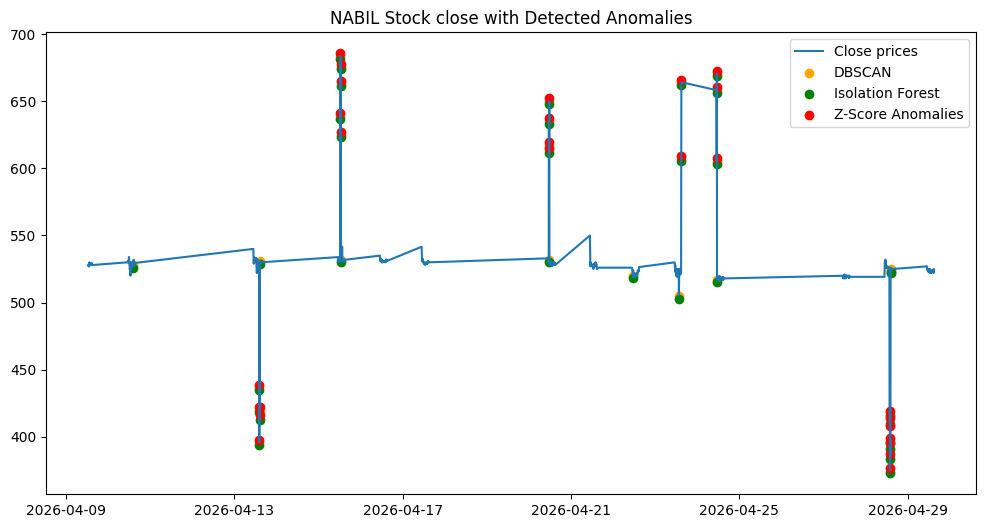

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["close"], label="Close prices")


plt.scatter(
    df[df["Anomaly_DBSCAN"] == -1].index,
    df[df["Anomaly_DBSCAN"] == -1]["close"],
    color="orange",
    label="DBSCAN",
)

plt.scatter(
    df[df["Anomaly_Isolation_Forest"] == -1].index,
    df[df["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
    color="green",
    label="Isolation Forest",
)

plt.scatter(
    anomalies_zscore.index,
    anomalies_zscore["close"] + 2,
    color="red",
    label="Z-Score Anomalies",
)

plt.title(f"{stock_name} Stock close with Detected Anomalies")
plt.legend()
plt.show()

In [20]:
import plotly.graph_objects as go


fig = go.Figure()

# Add the line for the closing close
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue"),
    )
)


# Add the scatter plot for Isolation Forest anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1].index,
        y=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
        mode="markers",
        name="Isolation Forest Anomalies",
        marker=dict(color="green", size=10),
    )
)

# Add the scatter plot for DBSCAN anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1].index,
        y=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1]["close"],
        mode="markers",
        name="DBSCAN Anomalies",
        marker=dict(color="orange", size=10),
    )
)

# Add the scatter plot for Z-Score anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"] + 2,
        mode="markers",
        name="Z-Score Anomalies",
        marker=dict(color="red", size=10),
    )
)


# Update layout
fig.update_layout(
    title=f"{stock_name} Stock close with Detected Anomalies",
    xaxis_title="Date",
    yaxis_title="Close prices",
    legend_title="Legend",
    width=1200,
    height=600,
)

# Show the plot
fig.show()

In [21]:
print(f"Injected Anomalies: {len(df[df["True_Anomaly"]==1])}")

print("Number of Z-Score Anomalies:", len(anomalies_zscore))
print(
    "Number of Isolation Forest Anomalies:",
    (df["Anomaly_Isolation_Forest"] == -1).sum()
)
print("Number of DBSCAN Anomalies:", sum(anomalies_dbscan["Anomaly_DBSCAN"] == -1))

Injected Anomalies: 21
Number of Z-Score Anomalies: 26
Number of Isolation Forest Anomalies: 32
Number of DBSCAN Anomalies: 30


## Results

**1. Precision:** When the model says its an anomaly, how often it is correct? (false positives)  
High Precision->Fewer false alarms  
Precision= TP/(TP+FP)

**2. Recall:** Out of all real anomalies. how many did we catch? (false negatives)  
High recall -> less anomalies missed
Recall = TP/(TP+FN)  

**3. F1-Score:** Balance between False positives and false negatives
Harmonic mean of precision and recall   
f1-score = 2*precision*recall/(precision+recall
)


Confusion Matrix for Z_Score:
[[615  10]
 [  5  16]]


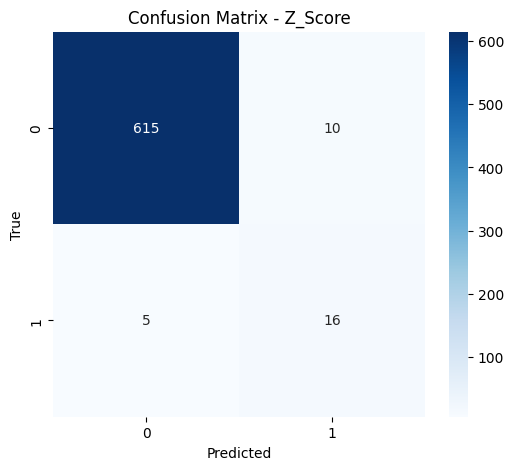


Confusion Matrix for Isolation_Forest:
[[614  11]
 [  0  21]]


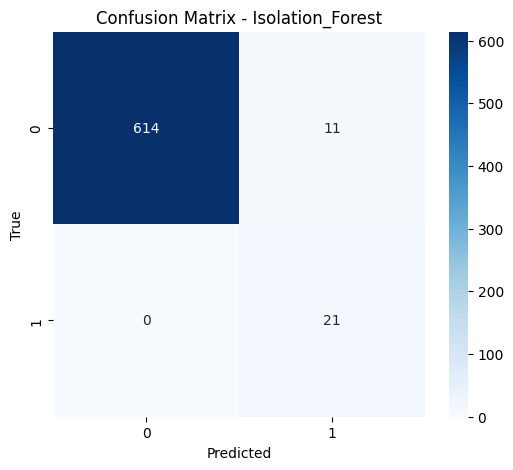


Confusion Matrix for DBSCAN:
[[616   9]
 [  0  21]]


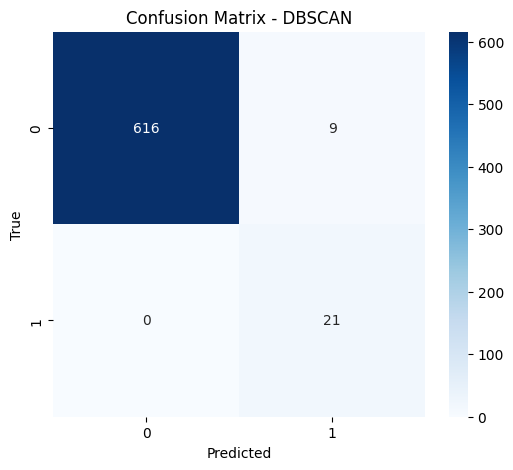


Comparison of all methods:
             Method  Precision    Recall  F1-Score
0           Z_Score   0.615385  0.761905  0.680851
1  Isolation_Forest   0.656250  1.000000  0.792453
2            DBSCAN   0.700000  1.000000  0.823529


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix,classification_report
import seaborn as sns



methods = ["Z_Score", "Isolation_Forest", "DBSCAN"]
results = []

for method in methods:
    if method == "Z_Score":
        predictions = (abs(df["Anomaly_Z_Score"]) > z_score_threshold).astype(int)
    elif method == "Isolation_Forest":
        predictions = (df["Anomaly_Isolation_Forest"] == -1).astype(int)
    elif method == "DBSCAN":
        predictions = (df["Anomaly_DBSCAN"] == -1).astype(int)

    precision = precision_score(df["True_Anomaly"], predictions)
    recall = recall_score(df["True_Anomaly"], predictions)
    f1 = f1_score(df["True_Anomaly"], predictions)
    # print(classification_report(df["True_Anomaly"], predictions));
    cm = confusion_matrix(df["True_Anomaly"], predictions)

    print(f"\nConfusion Matrix for {method}:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {method}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

    results.append(
        {"Method": method, "Precision": precision, "Recall": recall, "F1-Score": f1}
    )

results_df = pd.DataFrame(results)
print("\nComparison of all methods:")
print(results_df)